In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str,
    format_model_str_word_task,
    format_model_str_nsynth,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    marker_palette_for_hue,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    get_plot_groups,
    model_label,
    plot_grouped_bars,
)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re



## Get ESC 50 results for each model

In [124]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
# all_model_results += list(path_to_esc_results.rglob("*resnet*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
    
    if "resnet18" in path_str:
        if "barlow" in path_str:
            if "invar_augment" not in path_str and "audioset" not in path_str:
                continue
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']
    top1_std = np.std(results['avg_accuracies'])

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc, top1_std=top1_std)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')
esc_50_df['model_name'] = esc_50_df['model_name'].apply(normalize_model_name)
esc_50_df['task'] = 'ESC-50'
esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

esc_50_df = esc_50_df[~esc_50_df.model_name.str.contains('1.0|0.8|dual', na=False)]

array(['', '0.2', '0.4', '0.3', '0.5', '0.1', '0.0'], dtype=object)

## Get speech commands task results

In [66]:
path_to_speech_commands_results = Path("eval_jsin_results/linear_eval_speech_commands")
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*full*cosine*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*cosine*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if "equivariant" in path_str and not "cosine" in path_str:
        continue 


    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, _, eq_lmbda = format_model_str_word_task(results_path)
    if arch_class == 'unknown' and 'config_' in path_str:
        model_name = 'byol-a'
        arch_class = 'byol-a'
        eq_lmbda = ''
    
    # Remove audioset modifiers before normalization if we have explicit eq_lmbda
    # to prevent normalize_model_name from adding another lambda
    if eq_lmbda and 'ssl' in model_name:
        model_name = re.sub(
            r'\s+(?:jsin\s+)?audioset|\s+unbalanced\s+audioset',
            '',
            model_name,
        )
        model_name = re.sub(r'\s{2,}', ' ', model_name).strip()
    
    # Normalize the model name
    model_name = normalize_model_name(model_name)
    
    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    if model_name == 'byol-a':
        test_layer = 'final'

    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

speech_commands_df = pd.DataFrame.from_records(df_list)
speech_commands_df['test_layer'] = speech_commands_df['test_layer'].astype('str')
speech_commands_df['task'] = '20-word classification'

In [127]:
speech_commands_df.eq_lmbda.unique()

array(['', '0.5', '0.3', '0.0', '0.4', '0.1', '0.2'], dtype=object)

## Get word task results 

In [67]:
path_to_word_results = Path("eval_jsin_results")

kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# resnet18_word_results = list(path_to_word_results.rglob("*resnet18*.pkl"))
# resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# resnet50_word_results = list(path_to_word_results.rglob("*resnet50*.pkl"))
# resnet50_word_results = [path for path in resnet50_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + byola_results # + resnet18_word_results + resnet50_word_results +

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)

    # get learning rate from path. E.g. pattern AdamW_0.01_ should get 0.01, AdamW_1e-05 should get 1e-05
    try:
        pattern = r'AdamW_([0-9]+(?:\.[0-9]+)?(?:e-?[0-9]+)?)_'
        match = re.search(pattern, path_str)
        if match:
            learning_rate = match.group(1)
        else:
            learning_rate = None

    except:
        print(f"No learning rate found for {path_str}")
        learning_rate = None

    if learning_rate == "0.0005":
        if "scaled" not in model_name:
            continue
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, learning_rate=learning_rate)
    data = {**data, **results}


    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['model_name'] = word_df['model_name'].apply(normalize_model_name)
word_df['task'] = '800-word classification'

# get features layer from byola
word_df.loc[word_df.model_name.str.contains('byol-a'), 'arch_class'] = 'byol-a'

# drop byol-a rows where test_layer is not 'features'
word_df = word_df[~(word_df.model_name.str.contains('byol-a') & (word_df.test_layer != 'features'))]





In [128]:
word_df.eq_lmbda.unique()

array(['0.5', '0.0', '0.01', '', '0.3', '0.1', '0.4', '0.2'], dtype=object)

In [68]:
word_df[word_df.model_name.str.contains('byol-a')]

,model_name,arch_class,test_layer,eq_lmbda,learning_rate,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task
67,byol-a,byol-a,features,,0.002,0.434501,0.002565,0.997839,0.000166,1.0,0.0,0.999996,0.000004,800-word classification


In [69]:
path_to_nsynth_results = Path("eval_nsynth_results")

all_model_results = list(path_to_nsynth_results.rglob("audioset_*nsynth*.pkl"))
# all_model_results += list(path_to_nsynth_results.rglob("resnet18_barlow*nsynth*.pkl"))
# all_model_results += list(path_to_nsynth_results.rglob("resnet50_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("word_kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("config_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("byola*nsynth*.pkl"))

df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    results = pd.read_pickle(results_path)
    overall_acc = results['top1_mean']
    # Get error if available
    top1_sem = results.get('top1_sem', None)

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_nsynth(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if top1_sem is not None:
        data['top1_sem'] = top1_sem

    df_list.append(data)

nsynth_df = pd.DataFrame.from_records(df_list)
nsynth_df['test_layer'] = nsynth_df['test_layer'].astype('str')
nsynth_df['model_name'] = nsynth_df['model_name'].apply(normalize_model_name)
nsynth_df['task'] = 'NSynth'
nsynth_df = nsynth_df.loc[nsynth_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [129]:
nsynth_df.eq_lmbda.unique()

array(['', '0.4', '0.5', '0.0', '0.2', '0.3', '0.1'], dtype=object)

In [156]:
df = pd.concat([esc_50_df, speech_commands_df, word_df, nsynth_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,overall_acc,top1_std,task,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,learning_rate,speaker_top1_mean,speaker_top1_sem,speaker_top5_mean,speaker_top5_sem,top1_sem
0,CochDNN9 supervised multi-task,kell2018,preproc,,0.2485,0.019144,ESC-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CochDNN9 ssl λ=0.2,kell2018,preproc,0.2,0.2485,0.019144,ESC-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CochDNN9 ssl λ=0.4,kell2018,preproc,0.4,0.2480,0.018668,ESC-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CochDNN9 ssl λ=0.4,kell2018,preproc,0.4,0.2480,0.018668,ESC-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CochDNN9 ssl λ=0.3,kell2018,preproc,0.3,0.2485,0.019144,ESC-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [157]:
# make sure eq_lmbda is lambda in model_name for ssl models 

re_pattern = r'ssl λ=([0-9.]+)'
# df.loc[df.model_name.str.contains('ssl λ=', na=False), 'eq_lmbda'] = 
df.loc[df.model_name.str.contains('ssl λ=', na=False), 'eq_lmbda']  = df.loc[df.model_name.str.contains('ssl λ=', na=False)].model_name.str.extract(re_pattern)[0]
df.eq_lmbda.unique()
# df.head()

array(['', '0.2', '0.4', '0.3', '0.5', '0.1', '0.0', '0.01'], dtype=object)

# Plot Task results

### Make main figure plot with supervised models as reflines

In [132]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

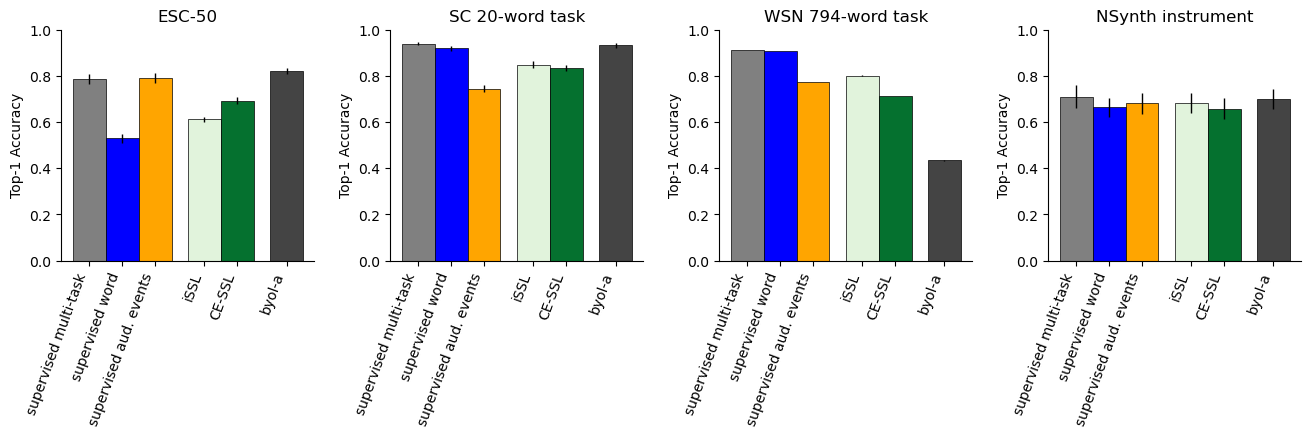

In [216]:
# Combine all data

# Filter: exclude scaled models, keep relu4 layer (or byol-a final/features)
# Only keep SSL models with lambda=0.0 or lambda=0.5
to_plot = df[
    ~df['model_name'].str.contains('scaled', na=False) &
    ~df['model_name'].str.contains('dual', na=False) &
    (
        df['test_layer'].str.contains('relu4', na=False) |
        ((df['model_name'] == 'byol-a') & df['test_layer'].str.contains('final|features', na=False, regex=True))
    ) &
    # Filter SSL models to only lambda=0.0 and lambda=0.5
    (
        ~df['model_name'].str.contains('ssl', na=False) |  # Keep non-SSL models
        (df['eq_lmbda'].isin(['0.0', '0.5', '', None]) | df['eq_lmbda'].isna())  # Keep SSL with lambda 0 or 0.5
    )
]

# Custom label function: lambda 0 -> iSSL, lambda 0.5 -> CE-SSL
def get_custom_label(model, eq_lmbda=None):
    label = model_label(model)
    if model.startswith('CochDNN9 ssl ') and 'scaled' not in model:
        if eq_lmbda in ['0.0', '', None] or pd.isna(eq_lmbda) or 'λ=0.0' in model:
            return 'iSSL'
        if eq_lmbda == '0.5':
            return 'CE-SSL'
    return label

# Define tasks and their value columns
tasks = [
    ('ESC-50', 'overall_acc', 'top1_std'),
    ('20-word classification', 'word_top1_mean', 'word_top1_sem'),
    ('800-word classification', 'word_top1_mean', 'word_top1_sem'),
    ('NSynth', 'overall_acc', 'top1_sem'),
]
titles = ['ESC-50', 'SC 20-word task', 'WSN 794-word task', 'NSynth instrument']

# Get model groups for ordering (not ranking)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)

# Define fixed order: Supervised, SSL (lambda 0 and 0.5 only), BYOL-A
plot_groups = [
    ('Supervised', supervised_names),
    ('SSL', ssl_names),
    ('BYOL-A', byol_names),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

bar_width = 1
group_gap = 0.5

for ax, (task, val_col, err_col), title in zip(axes, tasks, titles):
    # Get data for this task
    task_df = to_plot[to_plot['task'] == task].dropna(subset=[val_col])
    
    # Group by model and compute mean (no sorting - use fixed order)
    means = task_df.groupby('model_name')[val_col].mean()
    errors = task_df.groupby('model_name')[err_col].mean() if err_col in task_df.columns else None
    eq_lmbda_dict = task_df.groupby('model_name')['eq_lmbda'].first().to_dict()
    
    xticks = []
    xticklabels = []
    x_cursor = 0.1
    
    for group_name, models in plot_groups:
        # Filter to models that exist in this task's data
        models = [m for m in models if m in means.index]
        if len(models) == 0:
            continue
        
        for i, model in enumerate(models):
            x = x_cursor + i * bar_width
            color = hue_dict.get(model, '#666666')
            eq_lmbda = eq_lmbda_dict.get(model, None)
            label = get_custom_label(model, eq_lmbda)
            
            # Plot bar
            ax.bar(x, means.loc[model], width=bar_width, color=color, edgecolor='black', linewidth=0.5)
            
            # Add error bar (no cap)
            if errors is not None and model in errors.index:
                ax.errorbar(x, means.loc[model], yerr=errors.loc[model], fmt='none', color='black', capsize=0, linewidth=1)
            
            xticks.append(x)
            xticklabels.append(label)
        
        # Move cursor past this group plus the gap
        x_cursor += len(models) * bar_width + group_gap
    
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=70, ha='right')
    ax.set_ylabel('Top-1 Accuracy')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)

sns.despine()
plt.subplots_adjust(wspace=0.3)
# plt.tight_layout()

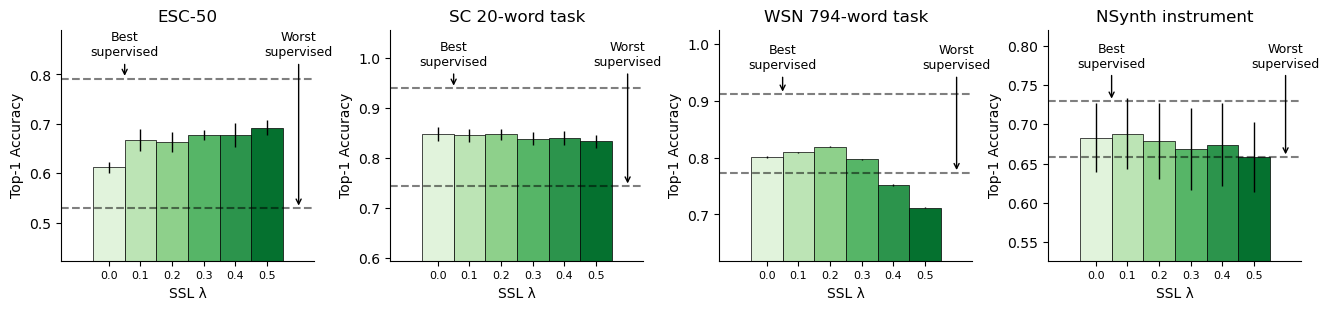

In [207]:

def add_supervised_reference_lines(
    ax,
    df,
    value_col="overall_acc",
    max_x_pos=0,
    min_x_pos=0,
    ylim_pad=(0.95, 1.05),
    fontsize=8,
):
    """
    Add dashed reference lines for best/worst supervised models with arrow annotations.

    Parameters
    ----------
    ax : matplotlib axes
        The axes to draw on
    df : pandas DataFrame
        DataFrame containing all models (will be filtered to supervised only)
    value_col : str
        Column name containing the metric values
    max_x_pos : float
        X position for the max annotation
    min_x_pos : float
        X position for the min annotation
    ylim_pad : tuple
        Padding (bottom, top) to add to ylim beyond the min/max values
    fontsize : int
        Font size for labels
    """
    sup_data = df[df.model_name.str.contains("sup", na=False)]

    if sup_data.empty:
        return None, None

    min_val, max_val = sup_data[value_col].agg(["min", "max"])

    ax.axhline(
        min_val,
        color="black",
        linestyle="--",
        alpha=0.5,
    )
    ax.axhline(
        max_val,
        color="black",
        linestyle="--",
        alpha=0.5,
    )

    ax.set_ylim(min_val * ylim_pad[0], max_val * ylim_pad[1])

    arrow_props = dict(arrowstyle="->", color="black", lw=1)

    ax.annotate(
        "Best\nsupervised",
        xy=(max_x_pos, max_val),
        xytext=(max_x_pos, max_val + 0.04),
        ha="center",
        va="bottom",
        fontsize=fontsize,
        arrowprops=arrow_props,
    )

    ax.annotate(
        "Worst\nsupervised",
        xy=(min_x_pos, min_val),
        xytext=(min_x_pos, max_val + 0.04),
        ha="center",
        va="bottom",
        fontsize=fontsize,
        arrowprops=arrow_props,
    )

    return min_val, max_val



# Simple bar plot helper
def simple_bar_plot(ax, data, value_col, error_col, title, ylabel, hue_dict, bar_width=1.0, x_pad=0.5):
    """Simple bar plot with lambda values on x-axis."""
    # Group by model and get means
    means = data.groupby('model_name')[value_col].mean()
    errors = data.groupby('model_name')[error_col].mean() if error_col else None
    
    # Sort by lambda value
    data = data.sort_values('eq_lmbda').copy()
    lambda_vals = data['eq_lmbda'].unique()
    models = data.model_name.unique()
    # Create x positions
    x = np.arange(len(models))  
    
    # Get colors and labels (just the number, no "λ=")
    colors = [hue_dict.get(model, '#444444') for model in models]
    labels = [re.search(r'λ=([0-9.]+)', m).group(1) if 'λ=' in m else m for m in models]
    
    # Plot bars
    bars = ax.bar(x, means, width=bar_width, color=colors, edgecolor='black', linewidth=0.5)
    
    # Add error bars if available
    ax.errorbar(x, means, yerr=errors, fmt='none', color='black', capsize=0, linewidth=1)
    
    # Set labels (no rotation)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('SSL λ')
    ax.set_xlim(-x_pad, len(x) + x_pad-1)
    
    return bars, labels

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

# Filter to SSL models with lambda values (all lambdas, excluding scaled)
lambda_plot_df = df[
    df.model_name.str.contains('ssl λ=', na=False) & 
    ~df.model_name.str.contains('scaled', na=False) &
    df.test_layer.str.contains('relu4', na=False)
].copy()


x_pad = 1.5
# Plot each panel (use correct task names from DataFrame)
esc_bars, esc_labels = simple_bar_plot(
    axes[0],
    lambda_plot_df[lambda_plot_df.task == 'ESC-50'],
    "overall_acc",
    "top1_std",
    "ESC-50",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)
sc_bars, sc_labels = simple_bar_plot(
    axes[1],
    lambda_plot_df[lambda_plot_df.task == '20-word classification'],
    "word_top1_mean",
    "word_top1_sem",
    "SC 20-word task",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)
word_bars, word_labels = simple_bar_plot(
    axes[2],
    lambda_plot_df[lambda_plot_df.task == '800-word classification'],
    "word_top1_mean",
    "word_top1_sem",
    "WSN 794-word task",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)

nsynth_bars, nsynth_labels = simple_bar_plot(
    axes[3],
    lambda_plot_df[lambda_plot_df.task == 'NSynth'],
    "overall_acc",
    "top1_sem",
    "NSynth instrument",
    "Top-1 Accuracy", 
    hue_dict, 
    bar_width=1.0, 
    x_pad=x_pad
)

# Add supervised model reference lines (use full df to find supervised models)
ylim_pad = (0.8, 1.125)
anot_fontsize = 9
for ax, task, val_col in [
    (axes[0], 'ESC-50', "overall_acc"),
    (axes[1], '20-word classification', "word_top1_mean"),
    (axes[2], '800-word classification', "word_top1_mean"),
    (axes[3], 'NSynth', "overall_acc"),
]:
    ref_data = df[(df.task == task) & df.test_layer.str.contains('relu4', na=False)]
    add_supervised_reference_lines(ax, ref_data, value_col=val_col, max_x_pos=0.5, min_x_pos=6, ylim_pad=ylim_pad, fontsize=anot_fontsize)

sns.despine()
plt.subplots_adjust(wspace=0.3)


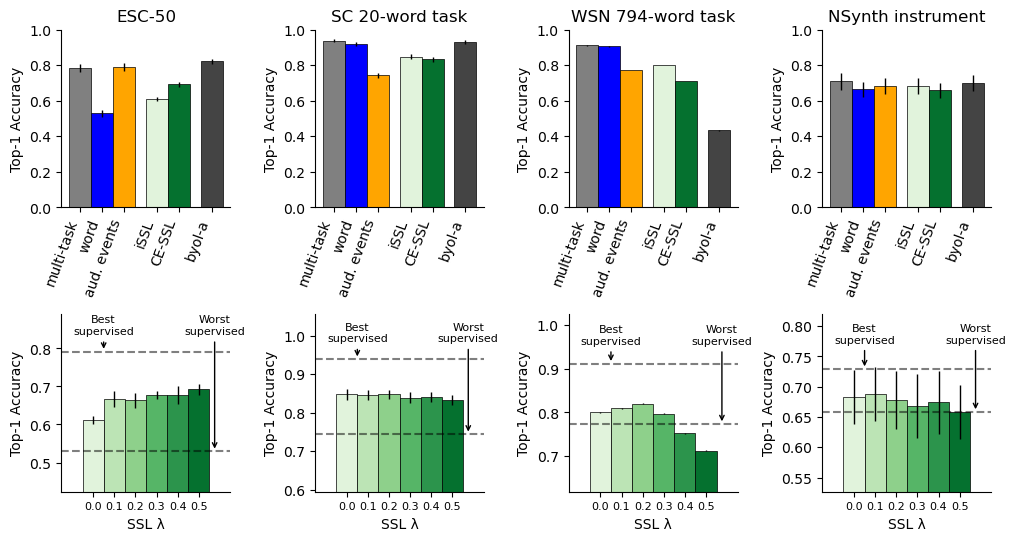

In [ ]:
# Combined figure: both plots as rows in the same figure

# Create 2x4 subplot figure (first plot uses 12x3, second uses 16x3, so use max width)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# ============ ROW 1: Model comparison bar plot ============
bar_width = 1
group_gap = 0.5

for ax, (task, val_col, err_col), title in zip(axes[0], tasks, titles):
    # Get data for this task
    task_df = to_plot[to_plot['task'] == task].dropna(subset=[val_col])
    
    # Group by model and compute mean (no sorting - use fixed order)
    means = task_df.groupby('model_name')[val_col].mean()
    errors = task_df.groupby('model_name')[err_col].mean() if err_col in task_df.columns else None
    eq_lmbda_dict = task_df.groupby('model_name')['eq_lmbda'].first().to_dict()
    
    xticks = []
    xticklabels = []
    x_cursor = 0.1
    
    for group_name, models in plot_groups:
        # Filter to models that exist in this task's data
        models = [m for m in models if m in means.index]
        if len(models) == 0:
            continue
        
        for i, model in enumerate(models):
            x = x_cursor + i * bar_width
            color = hue_dict.get(model, '#666666')
            eq_lmbda = eq_lmbda_dict.get(model, None)
            label = get_custom_label(model, eq_lmbda)
                        
            # Plot bar
            ax.bar(x, means.loc[model], width=bar_width, color=color, edgecolor='black', linewidth=0.5)
            
            # Add error bar (no cap)
            if errors is not None and model in errors.index:
                ax.errorbar(x, means.loc[model], yerr=errors.loc[model], fmt='none', color='black', capsize=0, linewidth=1)
            
            xticks.append(x)
            xticklabels.append(label)
        
        # Move cursor past this group plus the gap
        x_cursor += len(models) * bar_width + group_gap
    
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=70, ha='right')
    ax.set_ylabel('Top-1 Accuracy')
    # ax.set_xlabel('')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)

# ============ ROW 2: SSL lambda sweep with supervised reference lines ============

x_pad = 1.5
# Plot each panel (use correct task names from DataFrame)
esc_bars, esc_labels = simple_bar_plot(
    axes[1, 0],
    lambda_plot_df[lambda_plot_df.task == 'ESC-50'],
    "overall_acc",
    "top1_std",
    "", # "ESC-50",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)
sc_bars, sc_labels = simple_bar_plot(
    axes[1, 1],
    lambda_plot_df[lambda_plot_df.task == '20-word classification'],
    "word_top1_mean",
    "word_top1_sem",
    "", # "SC 20-word task",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)
word_bars, word_labels = simple_bar_plot(
    axes[1, 2],
    lambda_plot_df[lambda_plot_df.task == '800-word classification'],
    "word_top1_mean",
    "word_top1_sem",
    "", # "WSN 794-word task",
    "Top-1 Accuracy",
    hue_dict,
    bar_width=1.0,
    x_pad=x_pad
)

nsynth_bars, nsynth_labels = simple_bar_plot(
    axes[1, 3],
    lambda_plot_df[lambda_plot_df.task == 'NSynth'],
    "overall_acc",
    "top1_sem",
    "", # "NSynth instrument",
    "Top-1 Accuracy", 
    hue_dict, 
    bar_width=1.0, 
    x_pad=x_pad
)

# Add supervised model reference lines (use full df to find supervised models)
ylim_pad = (0.8, 1.125)
anot_fontsize = 8
for ax, task, val_col in [
    (axes[1, 0], 'ESC-50', "overall_acc"),
    (axes[1, 1], '20-word classification', "word_top1_mean"),
    (axes[1, 2], '800-word classification', "word_top1_mean"),
    (axes[1, 3], 'NSynth', "overall_acc"),
]:
    ref_data = df[(df.task == task) & df.test_layer.str.contains('relu4', na=False)]
    add_supervised_reference_lines(ax, ref_data, value_col=val_col, max_x_pos=0.5, min_x_pos=5.75, ylim_pad=ylim_pad, fontsize=anot_fontsize)

sns.despine()
plt.subplots_adjust(wspace=0.5, hspace=0.6)
# plt.tight_layout()

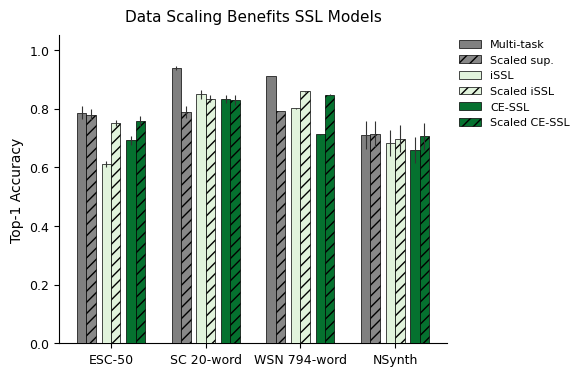

In [302]:
# Grouped bar plot: normal and scaled models comparison
# Order: multi-task, scaled supervised, iSSL, scaled iSSL, CE-SSL, scaled CE-SSL

# Filter to relu4 layer
plot_df = df[df['test_layer'].str.contains('relu4', na=False)].copy()

# Define tasks and their value/error columns
tasks_config = [
    ('ESC-50', 'overall_acc', 'top1_std'),
    ('20-word classification', 'word_top1_mean', 'word_top1_sem'),
    ('800-word classification', 'word_top1_mean', 'word_top1_sem'),
    ('NSynth', 'overall_acc', 'top1_sem'),
]
task_labels = ['ESC-50', 'SC 20-word', 'WSN 794-word', 'NSynth']

# Define model order with display labels and whether scaled (for hatching)
# (model_name_pattern, display_label, is_scaled)
model_configs = [
    ('CochDNN9 supervised multi-task', 'Multi-task', False),
    ('CochDNN9 scaled supervised', 'Scaled sup.', True),
    ('CochDNN9 ssl λ=0.0', 'iSSL', False),
    ('CochDNN9 scaled ssl λ=0.0', 'Scaled iSSL', True),
    ('CochDNN9 ssl λ=0.5', 'CE-SSL', False),
    ('CochDNN9 scaled ssl λ=0.5', 'Scaled CE-SSL', True),
]



# Create figure with better proportions
fig, ax = plt.subplots(figsize=(5, 4))

n_tasks = len(tasks_config)
n_models = len(model_configs)
group_gap = 0.06  # Gap between model groups (sup, iSSL, CE-SSL)
bar_width = 0.10  # Wider bars, less gap between them
x = np.arange(n_tasks)

# Add subtle horizontal grid
# ax.yaxis.grid(True, linestyle='-', alpha=0.2, color='gray', zorder=0)
ax.set_axisbelow(True)

# Plot bars for each model with gaps between groups
# Groups: [0,1] supervised, [2,3] iSSL, [4,5] CE-SSL
for i, (model_name, display_label, is_scaled) in enumerate(model_configs):
    means = []
    errors = []
    
    for task, val_col, err_col in tasks_config:
        task_data = plot_df[(plot_df['task'] == task) & (plot_df['model_name'] == model_name)]
        if not task_data.empty and val_col in task_data.columns:
            means.append(task_data[val_col].mean())
            errors.append(task_data[err_col].mean() if err_col in task_data.columns else 0)
        else:
            means.append(0)
            errors.append(0)
    
    # Get color from base palette
    # For scaled models, use the same color as their non-scaled counterpart (except scaled sup -> grey)
    if model_name == 'CochDNN9 scaled supervised':
        color = '#888888'  # Grey for scaled supervised
    elif model_name == 'CochDNN9 scaled ssl λ=0.0':
        color = hue_dict.get('CochDNN9 ssl λ=0.0', '#666666')  # Same as iSSL
    elif model_name == 'CochDNN9 scaled ssl λ=0.5':
        color = hue_dict.get('CochDNN9 ssl λ=0.5', '#666666')  # Same as CE-SSL
    else:
        color = hue_dict.get(model_name, '#666666')
    
    # Position bars with gaps between groups (after index 1 and 3)
    gap_offset = 0
    if i >= 2:  # After supervised group
        gap_offset += group_gap
    if i >= 4:  # After iSSL group
        gap_offset += group_gap
    
    offset = (i - n_models/2 + 0.5) * bar_width + gap_offset - group_gap
    
    # Use hatching for scaled models
    hatch = '///' if is_scaled else None
    
    bars = ax.bar(x + offset, means, bar_width, label=display_label, 
                  color=color, edgecolor='black', linewidth=0.5, 
                  hatch=hatch, zorder=3)
    ax.errorbar(x + offset, means, yerr=errors, fmt='none', color='#333333', 
                capsize=0, capthick=0.8, linewidth=0.8, zorder=4)

# Styling
ax.set_ylabel('Top-1 Accuracy', fontsize=10, fontweight='medium')
ax.set_title('Data Scaling Benefits SSL Models', fontsize=11, pad=10)
ax.set_xticks(x)
ax.set_xticklabels(task_labels, fontsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.set_ylim(0.0, 1.05)

# Improved legend - outside plot, organized
legend = ax.legend(loc='upper left', fontsize=8, frameon=False, 
                   bbox_to_anchor=(1.02, 1.0), borderaxespad=0,
                    ncol=1)
legend.get_frame().set_linewidth(0.5)

# Remove top and right spines for cleaner look
sns.despine(ax=ax, top=True, right=True)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# plt.tight_layout()

sns.despine()
# plt.tight_layout()